In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import matplotlib.dates as mdates


plt.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 9,
    'axes.titlesize'   : 10,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 9,
    'xtick.labelsize'  : 8,
    'ytick.labelsize'  : 8,
    'legend.fontsize'  : 8,
    'figure.dpi'       : 150,
})

# 1. Load Data

In [100]:
df = pd.read_csv('../../output/processed_data/04_Regression_handled.csv')

print('Shape    :', df.shape)
print('Day range:', df['day'].min(), 'to', df['day'].max())
print('\nSector names in data:')
print(df['sector'].value_counts().to_string())

Shape    : (52046, 23)
Day range: -196 to 60

Sector names in data:
sector
Food & Beverage               7923
Diversified Financials        7408
Capital Goods                 6870
Consumer Services             5113
Materials                     4420
Banks                         4112
Real Estate                   2806
Insurance                     2362
Utilities                     2297
Retailing                     2036
Healthcare Equipment          1782
Consumer Durables             1539
Energy                         767
Commercial Services            766
Telecommunication Services     514
Transportation                 500
Household Products             317
Software & Services            257
Automobiles                    257


In [101]:
# print(f'Number of records before deletion : {df.shape[0]}')
# df.drop(df[df['base_symbol'] == 'INME'].index,inplace = True)
# print(f'Number of records after deletion : {df.shape[0]}')
print(f"Post-cleaning: {df['symbol'].nunique()} instruments and {len(df)} records remain.")

Post-cleaning: 207 instruments and 52046 records remain.


## 2. Filters

**Filter 1 — Thin trading:**  Remove stocks with trading days < 60 in estimate window

**Filter 2 — Extreme beta:**  Removed stocks with extreme beta values (outliers)

**Filter 3 — Micro-sectors:**  Removed sectors with stocks < 5

In [102]:
# ── Filter 1: Thin trading ────────────────────────────────────────────────────
df['valid_est_day'] = (df['day'] >= -120) & (df['day'] <= -6) & df['R_i'].notnull()
trading_days = (
    df.groupby('symbol')['valid_est_day']
    .sum()
    .reset_index()
    .rename(columns={'valid_est_day': 'trading_days'})
)
sufficient    = trading_days[trading_days['trading_days'] >= 60]['symbol']
removed_thin  = trading_days[trading_days['trading_days'] <  60][['symbol', 'trading_days']]

print(f'Filter 1 — thin trading  : dropped {len(removed_thin)} stocks, kept {len(sufficient)}')
print('Removed stocks:')
print(removed_thin.sort_values('trading_days').to_string(index=False))
df = df[df['symbol'].isin(sufficient)].copy()
df = df.drop(columns=['valid_est_day'])

# ── Filter 2: Extreme beta ────────────────────────────────────────────────────
beta_per_stock = (
    df[(df['day'] >= -120) & (df['day'] <= -6)]
    .groupby('symbol')['beta']
    .first()
    .reset_index()
)

valid_beta    = beta_per_stock[
    (beta_per_stock['beta'] >= -3) &
    (beta_per_stock['beta'] <=  5)
]['symbol']
removed_beta  = beta_per_stock[
    (beta_per_stock['beta'] < -3) |
    (beta_per_stock['beta'] >  5)
][['symbol', 'beta']]

print(f'\nFilter 2 — extreme beta  : dropped {len(removed_beta)} stocks, kept {len(valid_beta)}')
print('Removed stocks:')
print(removed_beta.sort_values('beta', ascending=False).to_string(index=False))

df = df[df['symbol'].isin(valid_beta)].copy()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f'\nTotal stocks before filters : {len(trading_days)}')
print(f'Removed — thin trading      : {len(removed_thin)}')
print(f'Removed — extreme beta      : {len(removed_beta)}')
print(f'Final qualifying stocks     : {len(valid_beta)}')

Filter 1 — thin trading  : dropped 4 stocks, kept 203
Removed stocks:
    symbol  trading_days
INME.N0000             0
 JFP.N0000             1
MERC.N0000            19
SWAD.N0000            34

Filter 2 — extreme beta  : dropped 0 stocks, kept 203
Removed stocks:
Empty DataFrame
Columns: [symbol, beta]
Index: []

Total stocks before filters : 207
Removed — thin trading      : 4
Removed — extreme beta      : 0
Final qualifying stocks     : 203


## 3. Compute Abnormal Return (AR)
`AR = R_i − (alpha + beta × R_m)`

In [103]:


"""df['AR'] = df['R_i'] - (df['alpha'] + df['beta'] * df['R_m'])

# Sanity check — mean AR in estimation window should be ≈ 0
mean_ar = df[(df['day'] >= -120) & (df['day'] <= -6)]['AR'].mean()
print(f'Mean AR in estimation window: {mean_ar:.6f}')

est_df   = df[(df['day'] >= -120) & (df['day'] <= -6)].copy()
event_df = df[(df['day'] >= -5)   & (df['day'] <= 30)].copy()"""

"df['AR'] = df['R_i'] - (df['alpha'] + df['beta'] * df['R_m'])\n\n# Sanity check — mean AR in estimation window should be ≈ 0\nmean_ar = df[(df['day'] >= -120) & (df['day'] <= -6)]['AR'].mean()\nprint(f'Mean AR in estimation window: {mean_ar:.6f}')\n\nest_df   = df[(df['day'] >= -120) & (df['day'] <= -6)].copy()\nevent_df = df[(df['day'] >= -5)   & (df['day'] <= 30)].copy()"

Drop stocks with NaN alpha/beta before computing AR 

In [104]:
# Drop any stocks that have no alpha/beta (failed the min-30-obs regression filter).
# These stocks were never assigned parameters so AR would be NaN for their
# entire event window. Remove them here before computing AR.
# Drop stocks with no regression params (failed 30-obs OLS gate in NB04)
no_params = df['alpha'].isna() | df['beta'].isna()
dropped   = df[no_params]['symbol'].unique()
if len(dropped):
    print(f'Dropping {len(dropped)} stocks with no params: {list(dropped)}')
    df = df[~no_params].copy()

df['AR'] = df['R_i'] - (df['alpha'] + df['beta'] * df['R_m'])

# Sanity check — mean AR in estimation window should be exactly 0
mean_ar_est = df[(df['day'] >= -120) & (df['day'] <= -6)]['AR'].mean()
print(f'Mean AR in estimation window: {mean_ar_est:.8f}  (must be 0.0)')
assert abs(mean_ar_est) < 1e-10, 'Non-zero mean AR in estimation window — check regression'

# Define estimation and event window slices
est_df   = df[(df['day'] >= -120) & (df['day'] <= -6)].copy()
event_df = df[(df['day'] >= -5)   & (df['day'] <= 30)].copy()

print(f'Estimation window: {len(est_df):,} rows')
print(f'Event window     : {len(event_df):,} rows')
print(f'Qualifying stocks: {df["symbol"].nunique()}')

Mean AR in estimation window: 0.00000000  (must be 0.0)
Estimation window: 23,300 rows
Event window     : 7,246 rows
Qualifying stocks: 203


## 4. Compute CAR per Stock over the Event Window

In [105]:
# ── CAR anchored at Day 0 ─────────────────────────────────────────────────────
# Post-event (day >= 0): cumsum forward from Day 0
# Pre-event  (day <  0): cumsum backwards to Day 0 (negated)

def compute_anchored_car(group):
    group = group.sort_values('day').copy()

    post = group[group['day'] >= 0].copy()
    post['CAR_anchored'] = post['AR'].cumsum()

    pre = group[group['day'] < 0].sort_values('day', ascending=False).copy()
    pre['CAR_anchored'] = -pre['AR'].cumsum()
    pre = pre.sort_values('day')

    return pd.concat([pre, post]).sort_values('day')

#bug -looses symbol
#event_df = event_df.groupby('symbol', group_keys=False).apply(compute_anchored_car)

#event_df['CAR_pct'] = event_df['CAR_anchored'] * 100

# Sanity check — Day 0 CAR should equal AR(Day 0) for every stock
#day0 = event_df[event_df['day'] == 0]
#match = (day0['CAR_anchored'].round(8) == day0['AR'].round(8)).all()
#print(f'Day 0 sanity check passed: {match}')
#print(f'Mean AR in event window  : {event_df["AR"].mean():.6f}')

#---------------------------------------------------- fix

# Process each stock individually — symbol column is preserved naturally
pieces = []
for sym, grp in event_df.groupby('symbol'):
    pieces.append(compute_anchored_car(grp))

event_df = pd.concat(pieces).reset_index(drop=True)
event_df['CAR_pct'] = event_df['CAR_anchored'] * 100

# ── Sanity check — Day 0 CAR must equal AR(Day 0) for every stock ─────────────
day0    = event_df[event_df['day'] == 0]
failing = day0[day0['CAR_anchored'].round(8) != day0['AR'].round(8)]

if len(failing) > 0:
    print(f'Day 0 sanity check FAILED for {len(failing)} stocks:')
    print(failing[['symbol', 'day', 'AR', 'CAR_anchored']].to_string())
    raise ValueError(
        f'Day 0 CAR != AR for {len(failing)} stocks. '
        f'Check compute_anchored_car() or the AR calculation above.'
    )

print(f'✓ Day 0 sanity check passed for all {len(day0)} stocks')
print(f'  Mean AR in event window: {event_df["AR"].mean():.6f}')



✓ Day 0 sanity check passed for all 202 stocks
  Mean AR in event window: -0.000721


## 5. Aggregate Mean CAR by Sector and Day

In [106]:
sector_car = (
    event_df
    .groupby(['sector', 'day'])['CAR_pct']
    .mean()
    .reset_index()
    .rename(columns={'CAR_pct': 'mean_CAR_pct'})
)

print('Mean CAR on Day 0 by sector (cleaned):')
print(
    sector_car[sector_car['day'] == 0]
    .sort_values('mean_CAR_pct')
    .to_string(index=False)
)

Mean CAR on Day 0 by sector (cleaned):
                    sector  day  mean_CAR_pct
                    Energy    0     -1.164222
            Transportation    0     -1.096634
                 Utilities    0     -0.936934
         Consumer Services    0     -0.760646
       Commercial Services    0     -0.601045
    Diversified Financials    0     -0.502729
           Food & Beverage    0     -0.403221
         Consumer Durables    0     -0.260483
        Household Products    0     -0.120528
                 Insurance    0     -0.098222
               Automobiles    0     -0.059426
               Real Estate    0     -0.035001
                     Banks    0     -0.016412
             Capital Goods    0      0.074512
                 Materials    0      0.116091
       Software & Services    0      0.172953
      Healthcare Equipment    0      0.250691
Telecommunication Services    0      0.565565
                 Retailing    0      3.595650


In [107]:
market_car = {}

windows = {
    'CAR(-5,-1)' : (-5, -1),
    'CAR(0,0)'   : ( 0,  0),
    'CAR(0,+5)'  : ( 0,  5),
    'CAR(-5,+30)': (-5, 30),
}


for label, (t1, t2) in windows.items():
    window_data = event_df[(event_df['day'] >= t1) & (event_df['day'] <= t2)]
    stock_car = window_data.groupby('symbol')['AR'].sum() * 100
    market_car[label] = {
        'mean'   : round(stock_car.mean(), 3),
        'std'    : round(stock_car.std(), 3),
        'n'      : len(stock_car)
    }

market_df = pd.DataFrame(market_car).T
print('Market-level CAR summary:')
print(market_df.to_string())

Market-level CAR summary:
              mean     std      n
CAR(-5,-1)  -0.560   3.753  203.0
CAR(0,0)    -0.125   2.327  202.0
CAR(0,+5)   -2.044   6.023  203.0
CAR(-5,+30) -2.574  14.558  203.0


## Figure 0 — ASPI Index Trajectory
Daily ASPI close from Feb 2025 to Feb 2026 with landfall marker at Day 0.

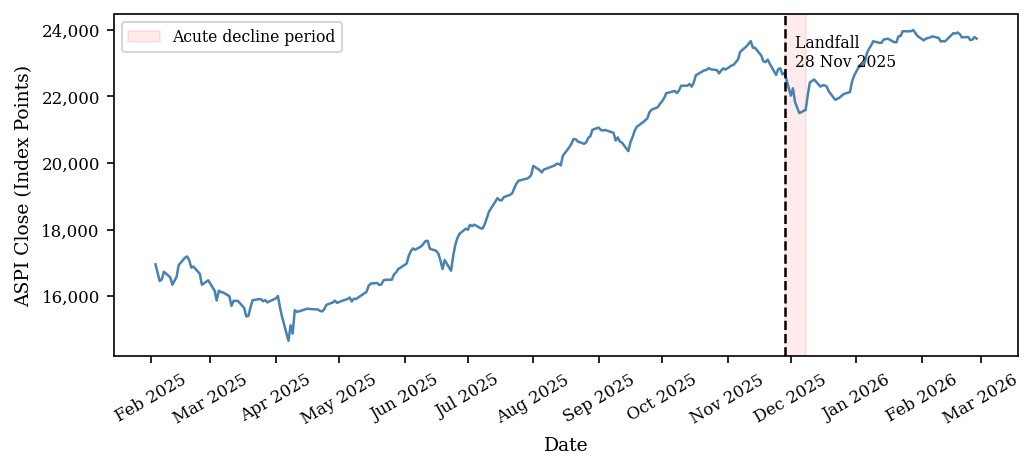

In [108]:
# ── ASPI trajectory: one row per trading date ────────────────────────────────
aspi_daily = (
    df[['date', 'day', 'aspi_close']]
    .drop_duplicates(subset='date')
    .sort_values('date')
    .reset_index(drop=True)
)

# Identify Day 0 date (landfall)
landfall_date = aspi_daily.loc[aspi_daily['day'] == 0, 'date'].values
if len(landfall_date) == 0:
    landfall_date = aspi_daily.loc[(aspi_daily['day'] - 0).abs().idxmin(), 'date']
else:
    landfall_date = landfall_date[0]

aspi_daily['date_dt'] = pd.to_datetime(aspi_daily['date'])
landfall_dt = pd.to_datetime(landfall_date)

fig0, ax0 = plt.subplots(figsize=(7, 3.2))

ax0.plot(
    aspi_daily['date_dt'],
    aspi_daily['aspi_close'],
    color='steelblue',
    linewidth=1.2,
    zorder=2
)

ax0.axvline(
    x=landfall_dt,
    color='black',
    linewidth=1.2,
    linestyle='--',
    zorder=3
)
ax0.text(
    landfall_dt,
    aspi_daily['aspi_close'].max() * 0.995,
    '  Landfall\n  28 Nov 2025',
    fontsize=7.5,
    va='top',
    color='black'
)

trough_date = aspi_daily.loc[(aspi_daily['day'] - 5).abs().idxmin(), 'date_dt']
ax0.axvspan(
    landfall_dt, trough_date,
    alpha=0.08, color='red', zorder=1,
    label='Acute decline period'
)

ax0.set_xlabel('Date')
ax0.set_ylabel('ASPI Close (Index Points)')

ax0.xaxis.set_major_locator(mdates.MonthLocator())
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax0.tick_params(axis='x', rotation=30)

ax0.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax0.legend(fontsize=7.5, loc='upper left')
plt.tight_layout()
fig0.savefig('../../output/figs/figure_aspi.pdf', bbox_inches='tight')
plt.show()


## Figure 1 — Sector CAR over the Event Window

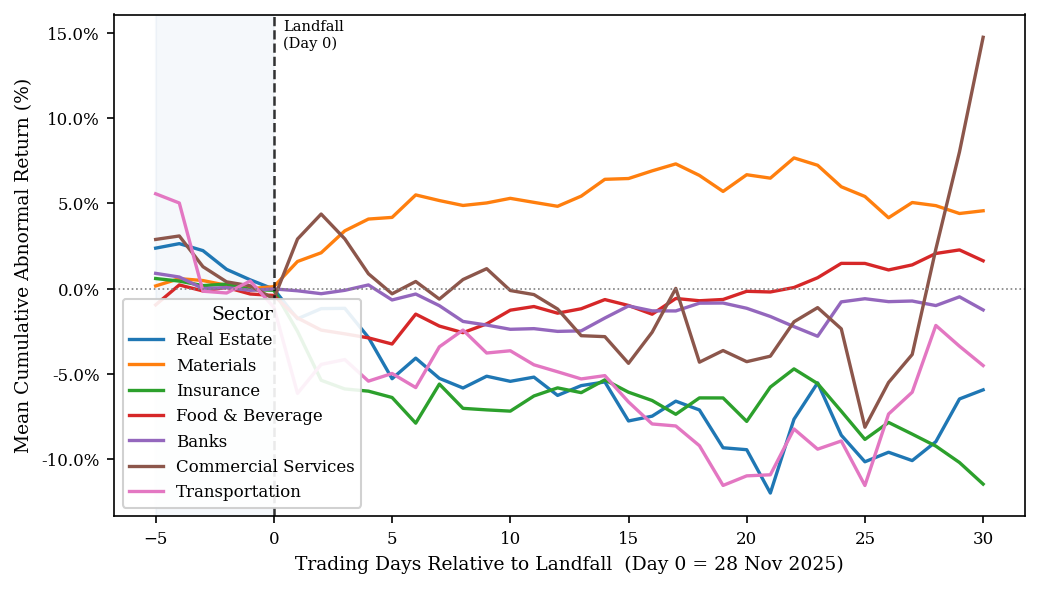

In [109]:
sectors = [
    'Real Estate',
    'Materials',
    'Insurance',
    'Food & Beverage',
    'Banks',
    'Commercial Services',
    'Transportation'
]

sector_car_plot = sector_car[sector_car['sector'].isin(sectors)].copy()
palette = sns.color_palette('tab10', n_colors=len(sectors))
col_map = dict(zip(sectors, palette))

fig1, ax1 = plt.subplots(figsize=(7, 4))

for sector in sectors:
    data = sector_car_plot[sector_car_plot['sector'] == sector].sort_values('day')
    ax1.plot(
        data['day'],
        data['mean_CAR_pct'],
        label=sector,
        color=col_map[sector],
        linewidth=1.6
    )

# Landfall marker
ax1.axvline(x=0, color='black', linewidth=1.2, linestyle='--', alpha=0.8)
ax1.text(0.4, ax1.get_ylim()[1] * 0.98,
         'Landfall\n(Day 0)', fontsize=7, color='black', va='top')

# Zero baseline
ax1.axhline(y=0, color='grey', linewidth=0.8, linestyle=':')

# Shade anticipation period
ax1.axvspan(-5, 0, alpha=0.05, color='steelblue')

ax1.set_xlabel('Trading Days Relative to Landfall  (Day 0 = 28 Nov 2025)')
ax1.set_ylabel('Mean Cumulative Abnormal Return (%)')
ax1.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax1.legend(title='Sector', loc='lower left', framealpha=0.9)

plt.tight_layout()
fig1.savefig('../../output/figs/figure1_sector_CAR.pdf', bbox_inches='tight')
plt.show()

## Figure 2 — Pre-Event Beta Distribution by Sector
Outliers beyond β ∈ [−3, 5] removed (thin-trading artefacts).

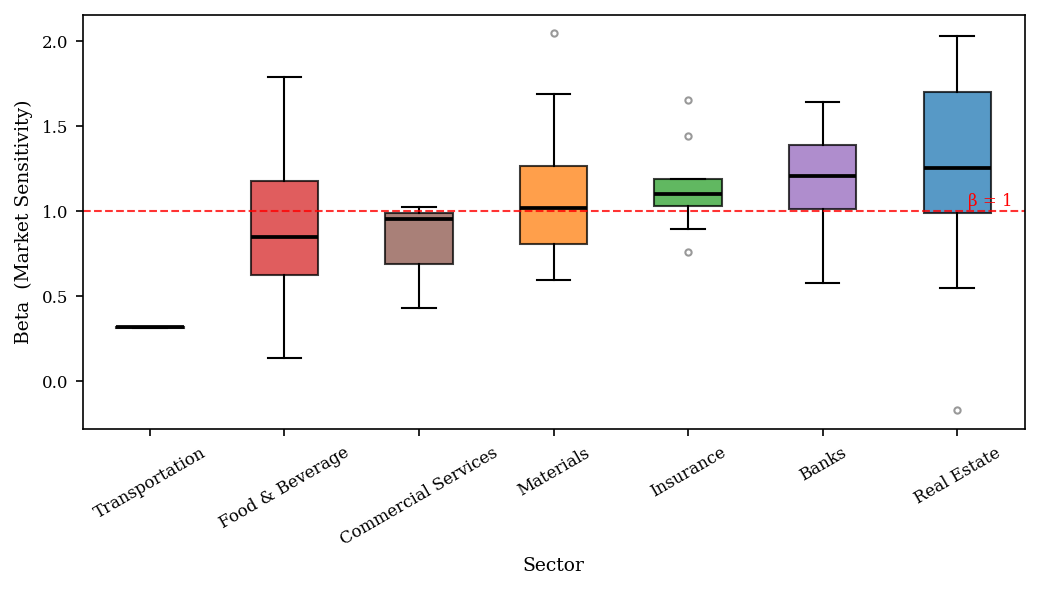

In [110]:
beta_per_stock = (
    est_df
    .groupby(['symbol', 'sector'])['beta']
    .first()
    .reset_index()
)

df_plot = beta_per_stock[beta_per_stock['sector'].isin(sectors)].copy()

# Sort by median beta low → high
sector_order = (
    df_plot.groupby('sector')['beta']
    .median()
    .sort_values()
    .index.tolist()
)

palette2 = [col_map[s] for s in sector_order]

fig2, ax2 = plt.subplots(figsize=(7, 4))

bp = ax2.boxplot(
    [df_plot[df_plot['sector'] == s]['beta'].values for s in sector_order],
    tick_labels=sector_order,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.8),
    flierprops=dict(marker='o', markersize=3, alpha=0.4, linestyle='none'),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1),
)

for patch, colour in zip(bp['boxes'], palette2):
    patch.set_facecolor(colour)
    patch.set_alpha(0.75)

ax2.axhline(y=1, color='red', linewidth=1, linestyle='--', alpha=0.8)
ax2.text(len(sector_order) + 0.08, 1.03, 'β = 1', fontsize=8, color='red')

ax2.set_xlabel('Sector')
ax2.set_ylabel('Beta  (Market Sensitivity)')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
fig2.savefig('../../output/figs/figure2_beta_by_sector.pdf', bbox_inches='tight')
plt.show()

In [111]:
rows = []
for sector in sorted(event_df['sector'].unique()):
    sec_df = event_df[event_df['sector'] == sector]
    row = {'Sector': sector}
    for label, (t1, t2) in windows.items():
        window_data = sec_df[
            (sec_df['day'] >= t1) &
            (sec_df['day'] <= t2)
        ]
        stock_car = window_data.groupby('symbol')['AR'].sum() * 100
        row[label] = round(stock_car.mean(), 2)
    rows.append(row)

car_table = pd.DataFrame(rows).set_index('Sector')
car_table = car_table.sort_values(by='CAR(-5,+30)', ascending=True)
print('CAR Summary Table (mean % per sector):')
print(car_table.to_string())

car_table.to_csv('../../output/tables/car_summary_table.csv')

CAR Summary Table (mean % per sector):
                            CAR(-5,-1)  CAR(0,0)  CAR(0,+5)  CAR(-5,+30)
Sector                                                                  
Energy                           -6.19     -1.16      -9.48       -17.93
Insurance                        -0.59     -0.10      -6.39       -12.07
Utilities                        -1.83     -0.94      -4.63       -11.67
Transportation                   -5.57     -1.10      -4.98       -10.09
Consumer Services                 1.87     -0.76      -6.75        -9.29
Real Estate                      -2.38     -0.04      -5.29        -8.32
Diversified Financials           -0.89     -0.50      -2.74        -6.32
Household Products                0.48     -0.12      -1.89        -4.36
Banks                            -0.90     -0.02      -0.67        -2.15
Healthcare Equipment             -0.77      0.25       0.71        -0.72
Automobiles                       1.40     -0.06      -0.88        -0.11
Capital Good

####  Per-stock CAR summary table 


In [112]:
# One row per qualifying stock showing CAR across all four event windows.
# This is the core output table sector averages are derived from these values.

rows = []
for sym, grp in event_df.groupby('symbol'):
    sector = grp['sector'].iloc[0]
    # Also pull alpha, beta, n_obs from the stock's estimation window data
    est_grp = est_df[est_df['symbol'] == sym]
    alpha   = est_grp['alpha'].iloc[0] if len(est_grp) > 0 else np.nan
    beta    = est_grp['beta'].iloc[0]  if len(est_grp) > 0 else np.nan
    n_obs   = len(est_grp.dropna(subset=['R_i', 'R_m']))

    row = {
        'symbol'     : sym,
        'sector'     : sector,
        'alpha'      : round(alpha, 6),
        'beta'       : round(beta, 4),
        'n_obs'      : n_obs,
    }
    for label, (t1, t2) in windows.items():
        window_data  = grp[(grp['day'] >= t1) & (grp['day'] <= t2)]
        row[label]   = round(window_data['AR'].sum() * 100, 4)
    rows.append(row)

per_stock_car = (
    pd.DataFrame(rows)
    .sort_values(['sector', 'CAR(-5,+30)'])
    .reset_index(drop=True)
)

print(f'Per-stock CAR table: {len(per_stock_car)} stocks across '
      f'{per_stock_car["sector"].nunique()} sectors')
print()
print('Within-sector dispersion (std of CAR(-5,+30)):')
print(
    per_stock_car.groupby('sector')['CAR(-5,+30)']
    .agg(['mean','std','min','max','count'])
    .round(2)
    .sort_values('mean')
    .to_string()
)

per_stock_car.to_csv('../../output/tables/per_stock_car.csv', index=False)
print()
print(f'✓ Saved per_stock_car.csv — {len(per_stock_car)} rows')

Per-stock CAR table: 203 stocks across 19 sectors

Within-sector dispersion (std of CAR(-5,+30)):
                             mean    std    min    max  count
sector                                                       
Energy                     -17.93  26.16 -37.94  11.67      3
Insurance                  -12.07   8.01 -22.86  -0.99      9
Utilities                  -11.67  12.96 -27.96   7.65      9
Transportation             -10.09   1.06 -10.84  -9.34      2
Consumer Services           -9.29   8.45 -28.98   1.28     20
Real Estate                 -8.32  17.74 -34.57  13.02     11
Diversified Financials      -6.32  11.74 -25.57  15.28     29
Household Products          -4.36    NaN  -4.36  -4.36      1
Banks                       -2.15   7.60 -18.36  10.87     16
Healthcare Equipment        -0.72  11.22 -13.36  20.43      7
Automobiles                 -0.11    NaN  -0.11  -0.11      1
Capital Goods                0.59  12.60 -29.93  25.08     27
Telecommunication Services   1.49 

In [113]:
df.isnull().sum()

symbol           0
date             0
open             0
high             0
low              0
close            0
volume           0
base_symbol      0
sector           0
suffix_cat       0
aspi_open        0
aspi_high        0
aspi_low         0
aspi_close       0
R_i            203
R_m            202
day              0
alpha            0
beta             0
r_squared        0
dw_stat          0
jb_pvalue        0
n_obs            0
AR             203
dtype: int64

In [114]:
df.to_csv('../../output/processed_data/05_filtered.csv', index=False)
print(f'✓ Saved 05_filtered.csv — {df["symbol"].nunique()} symbols, {len(df):,} rows')

✓ Saved 05_filtered.csv — 203 symbols, 51,779 rows
